In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ps = pd.read_csv('post_score_distribution.csv')

print(ps.shape)
print(ps.dtypes)
ps.head()

(312, 4)
level       int64
score       int64
mode       object
n_posts     int64
dtype: object


,level,score,mode,n_posts
0,0,0,quickplay,56174
1,0,1,quickplay,52321
2,0,2,quickplay,43179
3,0,3,quickplay,29123
4,0,4,quickplay,15832


In [3]:
quickplay = ps[ps['level'] == 0]
quickplay

,level,score,mode,n_posts
0,0,0,quickplay,56174
1,0,1,quickplay,52321
2,0,2,quickplay,43179
3,0,3,quickplay,29123
4,0,4,quickplay,15832
5,0,5,quickplay,6634
6,0,6,quickplay,2281
7,0,7,quickplay,638
8,0,8,quickplay,142
9,0,9,quickplay,34


In [4]:
level_mode = ps[ps['level'] > 0]

level_mode_per_score = level_mode.groupby('score')['n_posts'].sum()
level_mode_per_score

,n_posts
score,
0,5578
1,3859
2,3217
3,2615
4,1896
5,1852
6,1807
7,1675
8,1738


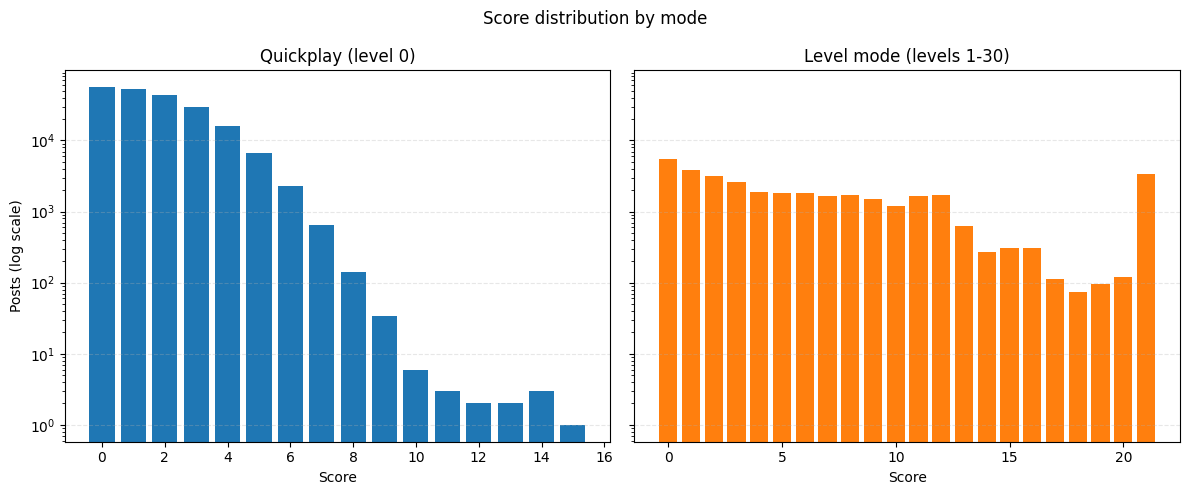

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].bar(quickplay['score'], quickplay['n_posts'], color='tab:blue')
axes[0].set_yscale('log')
axes[0].set_title('Quickplay (level 0)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Posts (log scale)')
axes[0].grid(alpha=0.3, linestyle='--', axis='y')

axes[1].bar(level_mode_per_score.index, level_mode_per_score.values, color='tab:orange')
axes[1].set_title('Level mode (levels 1-30)')
axes[1].set_xlabel('Score')
axes[1].grid(alpha=0.3, linestyle='--', axis='y')

fig.suptitle('Score distribution by mode')
plt.tight_layout()
plt.show()

In [6]:
level_mode_per_level = level_mode.groupby('level')['n_posts'].sum()
level_mode_per_level

,n_posts
level,
1,3947
2,3340
3,2969
4,2641
5,2064
6,1678
7,1407
8,1205
9,987


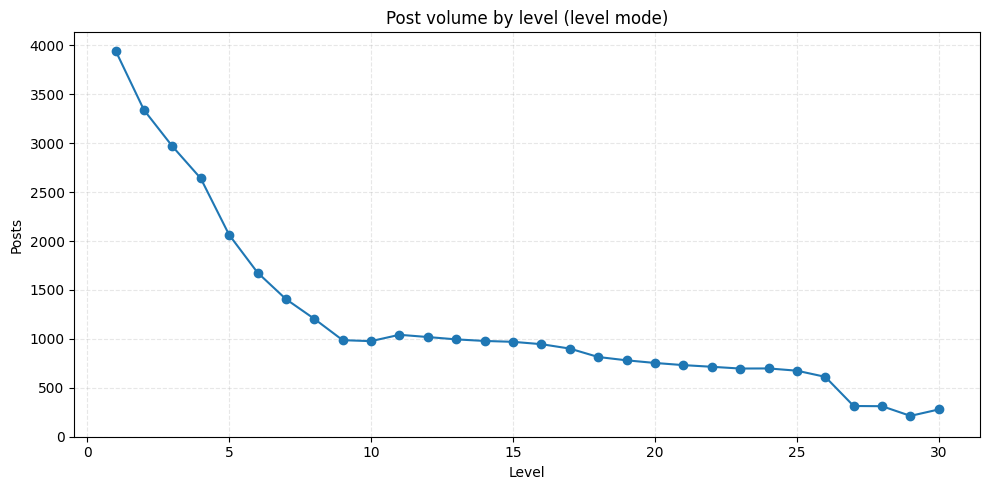

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(level_mode_per_level.index, level_mode_per_level.values, marker='o')
ax.set_xlabel('Level')
ax.set_ylabel('Posts')
ax.set_ylim(bottom=0)
ax.set_title('Post volume by level (level mode)')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [8]:
me = pd.read_csv('monetization_events.csv', parse_dates = ['event_date'])

print(me.shape)
print(me.dtypes)
me.head()

(1939, 10)
user_pseudo_id             object
event_date         datetime64[ns]
event_timestamp             int64
event_name                 object
product_id                 object
price                     float64
currency                   object
validated                 float64
type                       object
value                     float64
dtype: object


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value
0,00AE0CA4117376AE083FD6AEA744CE88,2018-09-02,1535943983925000,ad_reward,NaN,NaN,NaN,NaN,Steps,5.0
1,00AE0CA4117376AE083FD6AEA744CE88,2018-09-02,1535944080985000,ad_reward,NaN,NaN,NaN,NaN,Steps,5.0
2,014EE05605C94D797CA52C355638C967,2018-08-13,1534198373295000,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0
3,014EE05605C94D797CA52C355638C967,2018-08-13,1534198445681031,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0
4,014EE05605C94D797CA52C355638C967,2018-08-13,1534198451217008,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0


In [9]:
display(me['event_name'].value_counts())

me_purchases = me[me['event_name'] == 'in_app_purchase']
print(me_purchases.shape)
display(me_purchases)

,count
event_name,
ad_reward,1912
in_app_purchase,27


(27, 10)


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value
14,032918145D0FE92E31B0D5194DB1A4C3,2018-06-28,1530224360476000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0
206,1764DE126468943A92164D6E0063E36B,2018-06-28,1530235275743000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
211,18CB1F3F03C919DE0D79B07F291F7DB2,2018-06-26,1530061771028000,in_app_purchase,extra_steps_pack_3,4.99,USD,1.0,NaN,4990000.0
241,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0
253,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
260,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0
279,2E03DB1924573F3131EEC916E5444F56,2018-06-21,1529574302719000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
562,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0
779,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0
831,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0


In [10]:
day_0 = pd.read_csv('day_0.csv', parse_dates = ['day_0'])

print(day_0.shape)
print(day_0.dtypes)
day_0.head()

(4319, 2)
user_pseudo_id            object
day_0             datetime64[ns]
dtype: object


,user_pseudo_id,day_0
0,1814A35D096333518F94B02DDFE3BFEC,2018-06-15
1,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15
2,6B41795D5E5B7339E007330941C9E201,2018-06-15
3,0FB42D5FFB79A9DE147873753BF7A664,2018-07-15
4,61C77C8D9E7F92524289DA7E9D4786BF,2018-07-15


In [11]:
days_to_purchase = pd.merge(me_purchases, day_0, on = 'user_pseudo_id', how = 'left')
display(days_to_purchase)

days_to_purchase['days_to_purchase'] = (days_to_purchase['event_date'] - days_to_purchase['day_0']).dt.days
print()
display(days_to_purchase.sort_values('days_to_purchase', ascending = False))

,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value,day_0
0,032918145D0FE92E31B0D5194DB1A4C3,2018-06-28,1530224360476000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,NaT
1,1764DE126468943A92164D6E0063E36B,2018-06-28,1530235275743000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,NaT
2,18CB1F3F03C919DE0D79B07F291F7DB2,2018-06-26,1530061771028000,in_app_purchase,extra_steps_pack_3,4.99,USD,1.0,NaN,4990000.0,NaT
3,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0,2018-08-01
4,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-09-19
5,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0,2018-09-20
6,2E03DB1924573F3131EEC916E5444F56,2018-06-21,1529574302719000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,NaT
7,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0,2018-07-31
8,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-08-07
9,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-12


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value,day_0,days_to_purchase
20,C021984971708350A5394E695922BF35,2018-09-20,1537483412522000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-08-13,38.0
4,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-09-19,6.0
21,C4D5047D953E47CF2ECFF6E827420A99,2018-10-02,1538493768383000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-29,3.0
12,6C07A737EA896840697ACE56AC23A3A9,2018-06-17,1529297497829000,in_app_purchase,extra_steps_pack_1,0.99,USD,NaN,NaN,990000.0,2018-06-15,2.0
13,7107B8B93B285616D099D9010F6AD834,2018-09-05,1536172501371000,in_app_purchase,extra_steps_pack_1,0.99,USD,1.0,NaN,990000.0,2018-09-04,1.0
3,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0,2018-08-01,0.0
7,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0,2018-07-31,0.0
8,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-08-07,0.0
5,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0,2018-09-20,0.0
9,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-12,0.0


In [12]:
dtp = days_to_purchase['days_to_purchase'].dropna()

print('cohort buyers:          ', dtp.shape[0])
print('purchased on day 0:     ', (dtp == 0).sum())
print('share purchasing day 0: ', round(100 * (dtp == 0).mean(), 1), '%')
print('median days to purchase:', dtp.median())
display(dtp.describe())

cohort buyers:           17
purchased on day 0:      12
share purchasing day 0:  70.6 %
median days to purchase: 0.0


,days_to_purchase
count,17.000000
mean,2.941176
std,9.175174
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,38.000000


In [13]:
days_to_purchase['product_id'].value_counts()

,count
product_id,
remove_ads,20
extra_steps_pack_1,5
extra_steps_pack_3,1
extra_steps_pack_2,1
